In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats.mstats import winsorize

In [232]:
np.random.seed(42)

In [233]:
feat_1 = np.random.normal(loc=60, scale=6, size=200)

In [234]:
feat_2 = np.random.exponential(scale=60, size=200)

In [235]:
f = np.random.normal(loc=15, scale=3, size=195)
feat_3 = np.append(f, [f.max()+50, f.max()+100, f.max()+150, f.max()+200, f.max()+250])

In [236]:
df = pd.DataFrame({'Normal': feat_1,'Skewed': feat_2,'with_outliner': feat_3})

In [237]:
df.head(2)

,Normal,Skewed,with_outliner
0,62.980285,125.916518,14.673720
1,59.170414,81.002055,16.205135


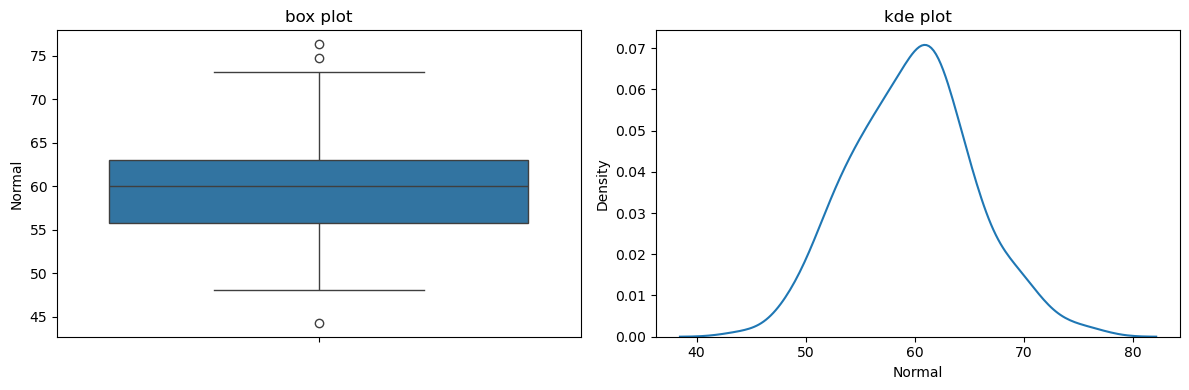

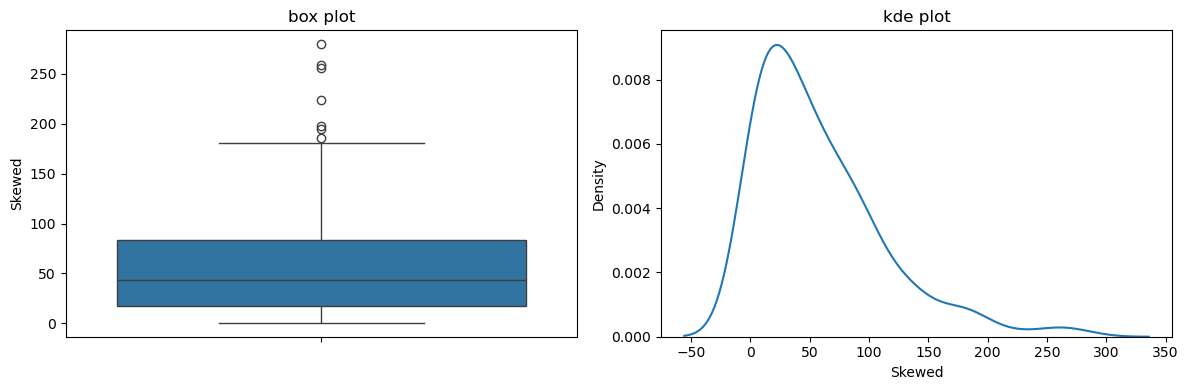

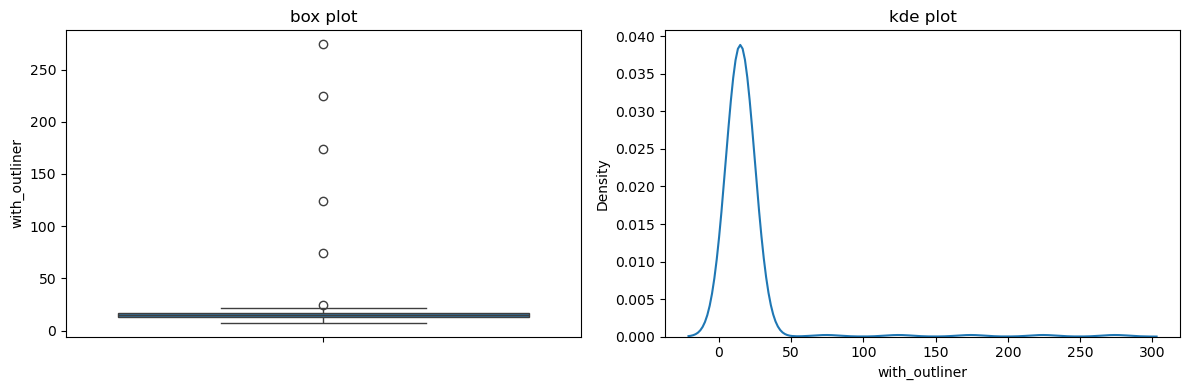

In [238]:
for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(df[col], ax=axes[0]).set_title('box plot')
    sns.kdeplot(df[col], ax=axes[1]).set_title('kde plot')
    
    plt.tight_layout()
    plt.show()


In [239]:
minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

In [240]:
minmaxscaled = minmax.fit_transform(df)
standardscaled = standard.fit_transform(df)
robustscaled = robust.fit_transform(df)

In [241]:
df_minmax = pd.DataFrame(minmaxscaled, columns=df.columns)
df_standard = pd.DataFrame(standardscaled, columns=df.columns)
df_robust = pd.DataFrame(robustscaled, columns=df.columns)

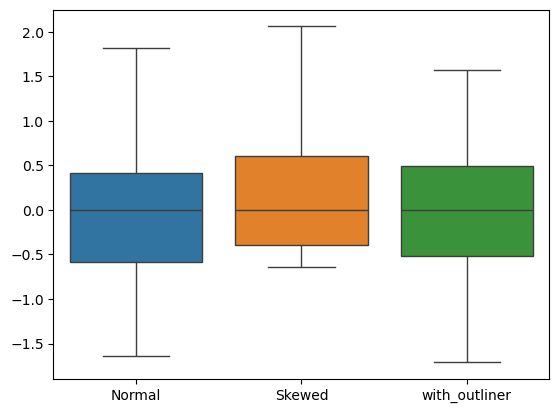

In [242]:
sns.boxplot(df_robust, showfliers=False);

In [243]:
df.columns

Index(['Normal', 'Skewed', 'with_outliner'], dtype='object')

In [244]:
df_bounding = df.copy()
df_bounding['without_outliner'] = np.clip(df['with_outliner'], 0, 200)

<Axes: ylabel='without_outliner'>

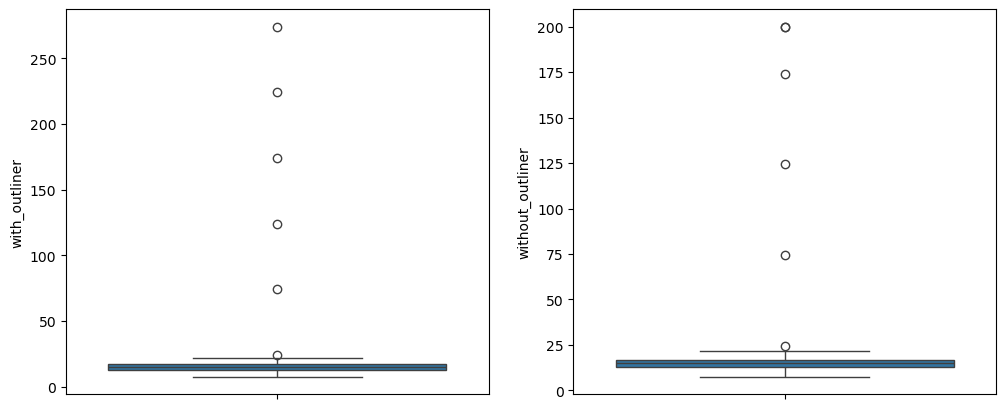

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(df['with_outliner'], ax=axes[0])
sns.boxplot(df_bounding['without_outliner'], ax=axes[1])

In [246]:
df_winsorize = df.copy()
df_winsorize['without_outliner'] = winsorize(df['with_outliner'], [0.05, 0.05])

<Axes: ylabel='without_outliner'>

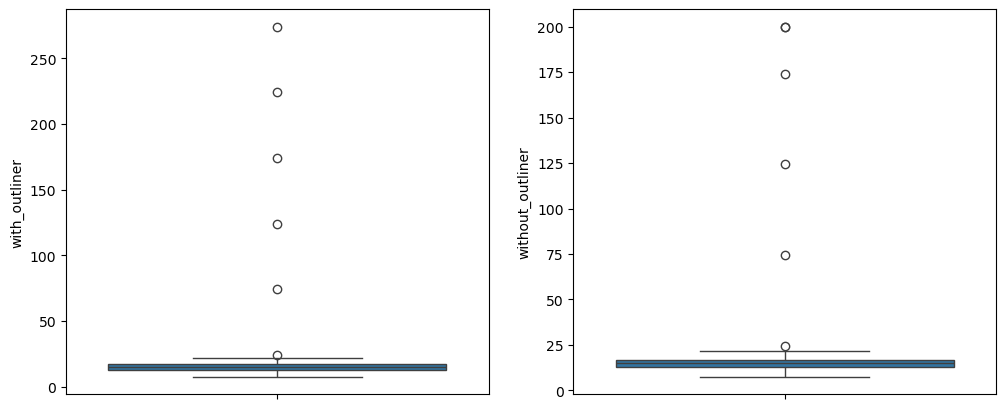

In [247]:
fix, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(df['with_outliner'], ax=axes[0])
sns.boxplot(df_bounding['without_outliner'], ax=axes[1])